# JJ current-current correlator -- MASSLESS valence (single ensemble)

Load-only **combiner** notebook for ONE ensemble at MASSLESS valence ($m_F=m_P=0$).  The heavy work
(inversions, disc post-processing, later reweighting $R$) is done by the run script; here we only
**load** the produced `corr_*.h5` (connected + raw disc traces) and `disc_proced.*.h5` (disc two-point),
jackknife, and combine.  Procedure reference: `jj_analysis_global_procedure_claude.md`.

Independent blocks: **conn tp / sp / ylm** (each = vector `Vpp/Vmm` + axial `Apm`), **disc** (vector only),
**sum** ($-\mathrm{conn}+\mathrm{disc}$, Eq. 3.39).  Free massless is validated against the analytical
expressions of arXiv:2510.03085 (overlay TODO in the sum block).  Separate notebooks exist for $m_F$ / $m_P$;
cross-mass comparison is a separate export/read notebook.

In [1]:
import h5py
import os
import glob
import math
import numpy as np
import matplotlib.pyplot as plt
from natsort import natsorted

In [2]:
# --- auto-save each displayed figure as its own PDF (figs_jj_corr_massless/) ---
# One cell, non-invasive: a post_run_cell hook saves every NEW figure after each cell runs.
# Re-run the notebook (Run All) to (re)generate the PDFs.  Names = NN_<first-axes-title>.pdf.
import os
from IPython import get_ipython
_ip = get_ipython()
if _ip is not None:
    _ip.run_line_magic("config", "InlineBackend.close_figures = False")  # keep figs open so we can save them
plt.rcParams["figure.max_open_warning"] = 0

FIGDIR = "figs_jj_corr_massless"
os.makedirs(FIGDIR, exist_ok=True)
_pdf_n = [0]
def _save_new_figs(result=None):
    for num in plt.get_fignums():
        fig = plt.figure(num)
        if getattr(fig, "_pdf_saved", False):
            continue
        fig._pdf_saved = True
        _pdf_n[0] += 1
        ttl = ""
        try:
            axs = fig.get_axes()
            if axs:
                ttl = axs[0].get_title()
        except Exception:
            pass
        ttl = "".join(c if (c.isalnum() or c in "-+") else "_" for c in ttl).strip("_")[:40]
        name = f"{_pdf_n[0]:02d}_{ttl}" if ttl else f"fig_{_pdf_n[0]:02d}"
        fig.savefig(os.path.join(FIGDIR, name + ".pdf"), bbox_inches="tight")

if _ip is not None:
    for _cb in list(_ip.events.callbacks.get("post_run_cell", [])):
        if getattr(_cb, "__name__", "") == "_save_new_figs":
            _ip.events.unregister("post_run_cell", _cb)
    _ip.events.register("post_run_cell", _save_new_figs)
print(f"figures -> {FIGDIR}/NN_<title>.pdf (one PDF per figure)")

figures -> figs_jj_corr_massless/NN_<title>.pdf (one PDF per figure)


In [3]:
# ---- jackknife (resampling over the LAST stat axis = configs) ----
class Jackknife:
    def __init__(self, len_data, binsize):
        self.binsize = binsize
        self.nbins = math.floor(len_data / self.binsize)
        self.N = self.binsize * self.nbins
        self.jack_avg = []
        self.est = 0
        self.var_est = 0
    def set(self, func, list_of_data):
        for i in range(self.nbins):
            self.jack_avg.append(func(i, self.binsize, list_of_data))
    def do_it(self):
        for i in range(self.nbins): self.est += self.jack_avg[i]
        self.est /= self.nbins
        for i in range(self.nbins): self.var_est += (self.jack_avg[i] - self.est) ** 2
        self.var_est /= self.nbins
        self.var_est *= self.nbins - 1
    def mean(self): return self.est
    def err(self):  return np.sqrt(self.var_est)

def simple_mean(i, binsize, np_data):
    return np.mean(np.delete(np_data, np.s_[i*binsize:(i+1)*binsize], axis=0), axis=0)

## Block 0 -- ensemble id + load (the START)

Set the ensemble (`ens`: `'free'` for the U=1 check, or an interacting `--ens-dir` basename) and the
MASSLESS valence.  The notebook ASSERTS the designated mass pattern.

In [4]:
# ===== Block 0: ENSEMBLE ID + parameters (MASSLESS) =====
gsq = "8.000000"; at = "0.200000"; Nt = 128; L = 1; nu0 = "1.000000"
current = "vector"

# free vs interacting: 'free' (U=1 check) or the --ens-dir basename of an interacting ensemble.
# ---- FREE CASE (commented out; was the U=1 check) ----
# ens = 'free'
# Nf = 2
# nhits = 64        # free --all run used 64 hits
# ---- INTERACTING massless-sea ensembles (Nf=2 / Nf=4); pick ONE ----
Nf = 2; ens = 'Nf%d_gsq8.000000at0.200000nu01.000000nt128L1' % Nf
# Nf = 4; ens = 'Nf%d_gsq8.000000at0.200000nu01.000000nt128L1' % Nf
nhits = 1          # interacting run used --nhits 1

# Valence mass for THIS notebook = MASSLESS.  Assert the designated pattern.
mre, mim = 0.0, 0.0
assert (mre == 0.0) and (mim == 0.0), "MASSLESS notebook: require (mre,mim)==(0,0)."
parity = False   # massless: Vmm = conj(Vpp); axial uses massless D_ov on both legs

n_t0 = 2          # match --n-t0 used in the run
# read cap: load ONLY corr.<k>/disc_proced.<k> with k <= kmax_read.  Set this BELOW the running
# corr job's current frontier so the loaders never touch the file being written (None => all).
kmax_read = 1000  # upper read cap: load ONLY k <= kmax_read (None => all, incl. in-progress).
                  # NOTE configs are trajectory-indexed with stride 10 (corr.10, corr.20, ...),
                  # so kmax_read=100 keeps k=10..100; for the first 100 configs use kmax_read=1000.
kmin_therm = 100  # thermalization cut: jackknife ONLY configs with k >= kmin_therm (see Block therm).
binsize = 1
dir1 = '/mnt/barracuda22/qed3/qed3/src/both_3d/'

# ---- resampling unit (the jackknife statistical sample) ----
# FREE (ens=='free'): the gauge field is fixed (U=1), so the stochastic HITS are the ensemble ->
#   resample over hits (averaging only the correlated t0 origins within a hit).
# INTERACTING: each gauge CONFIG is an independent sample; hits are correlated noise on a shared
#   background -> average over (h,t0) per config and resample over configs.
resample = 'hits' if ens == 'free' else 'configs'   # override here if needed

def esnid():    return ens + '_vmRe%.6fvmIm%.6f' % (mre, mim)
def corr_dir(): return dir1 + 'data_' + esnid() + '/corr_nt0%d_nhits%d/' % (n_t0, nhits)
xxx = float(at) * np.arange(Nt)

print('ensemble id (esnid) =', esnid(), '(free U=1)' if ens == 'free' else '(interacting)')
print('corr dir            =', corr_dir())
print('resample over       =', resample, '(free=>hits, interacting=>configs)')

ensemble id (esnid) = Nf2_gsq8.000000at0.200000nu01.000000nt128L1_vmRe0.000000vmIm0.000000 (interacting)
corr dir            = /mnt/barracuda22/qed3/qed3/src/both_3d/data_Nf2_gsq8.000000at0.200000nu01.000000nt128L1_vmRe0.000000vmIm0.000000/corr_nt02_nhits1/
resample over       = configs (free=>hits, interacting=>configs)


In [5]:
# ===== loaders (LOAD-ONLY).  corr_*.h5 = conn + raw disc J; disc_proced.*.h5 = disc two-point. =====
# The jackknife SAMPLE axis follows `resample` (block 0): 'hits' -> one sample per hit (t0-averaged,
# config fixed; free); 'configs' -> one sample per config ((h,t0)-averaged; interacting).
#
# CONCURRENT-WRITE SAFE: these run while the corr job is STILL writing.  We open read-only with
# locking=False (else HDF5 raises BlockingIOError errno 11 against the writer's lock), and wrap each
# file's reads in try/except: a config caught mid-truncate has an inconsistent header and raises
# RuntimeError -> we skip it (its 'complete' sentinel is absent anyway, so it is never used).
def _open_ro(fn):
    try:    return h5py.File(fn, 'r', locking=False)
    except OSError: return None

def _ck(fn):   # parse ckpoint index k from ".../<name>.<k>.h5"
    return int(fn.rsplit('.', 2)[-2])

def _corr_files():
    # kmax_read (block 0): read ONLY configs with k <= kmax_read.  Set it below the running job's
    # current frontier so we never open the in-progress file (None => read all, incl. in-progress).
    # Lower bound kmin_therm (block 0) drops the unthermalized transient (jackknife uses [kmin_therm:]).
    fns = natsorted(glob.glob(corr_dir() + 'corr.*.h5'))
    return [fn for fn in fns if _ck(fn) >= kmin_therm and (kmax_read is None or _ck(fn) <= kmax_read)]

def _dp_files():
    fns = natsorted(glob.glob(corr_dir() + 'disc_proced.*.h5'))
    return [fn for fn in fns if _ck(fn) >= kmin_therm and (kmax_read is None or _ck(fn) <= kmax_read)]

def _hits(f):
    return natsorted(k for k in f.keys() if k.startswith('h') and k[1:].isdigit())

def _t0s(f, hk):
    return natsorted(k for k in f[hk].keys() if k.startswith('t0_'))

def _complete(f):   # jj_corr / jj_disc_postproc 'complete' sentinel (written LAST)
    return 'complete' in f

def load_conn(leaf):
    '''(nsamp, Nt) complex.  leaf e.g. "tp/Vpp", "sp/Vmm", "axial/tp/Apm".
       resample=hits: one t0-averaged row per HIT; configs: one (h,t0)-averaged row per config.'''
    samp = []
    for fn in _corr_files():
        f = _open_ro(fn)
        if f is None: continue
        try:
            with f:
                if not _complete(f): continue
                def get(hk, tk):
                    k = '%s/%s/%s' % (hk, tk, leaf)
                    return (f[k + '/real'][:] + 1j*f[k + '/imag'][:]) if (k + '/real') in f else None
                if resample == 'hits':
                    for hk in _hits(f):
                        a = [g for tk in _t0s(f, hk) if (g := get(hk, tk)) is not None]
                        if a: samp.append(np.mean(a, axis=0))
                else:
                    a = [g for hk in _hits(f) for tk in _t0s(f, hk) if (g := get(hk, tk)) is not None]
                    if a: samp.append(np.mean(a, axis=0))
        except (OSError, RuntimeError):
            continue
    return np.array(samp)

def load_ylm_conn(ch='Vpp'):
    '''(nsamp, n_ell, Nt) complex + ls, with the same resample sampling as load_conn.'''
    samp, ls = [], None
    for fn in _corr_files():
        f = _open_ro(fn)
        if f is None: continue
        try:
            with f:
                if not _complete(f) or 'ls' not in f: continue
                ls = f['ls'][:]
                def tower(pairs):
                    G = np.zeros((len(ls), Nt), dtype=complex)
                    for (hk, tk) in pairs:
                        for li, l in enumerate(ls):
                            k = '%s/%s/ylm/%s/l%d/' % (hk, tk, ch, l)
                            G[li] += f[k + 'real'][:] + 1j*f[k + 'imag'][:]
                    return G / len(pairs)
                if resample == 'hits':
                    for hk in _hits(f):
                        samp.append(tower([(hk, tk) for tk in _t0s(f, hk)]))
                else:
                    samp.append(tower([(hk, tk) for hk in _hits(f) for tk in _t0s(f, hk)]))
        except (OSError, RuntimeError):
            continue
    return np.array(samp), ls

def load_rawJ(leaf):
    '''(nsamp, Nt) complex: RAW disc single-current trace h{h}/disc/<leaf>.
       resample=hits: one sample per hit; configs: h-averaged per config.  leaf e.g. "tp/J".'''
    samp = []
    for fn in _corr_files():
        f = _open_ro(fn)
        if f is None: continue
        try:
            with f:
                if not _complete(f): continue
                def get(hk):
                    k = '%s/disc/%s' % (hk, leaf)
                    return (f[k + '/real'][:] + 1j*f[k + '/imag'][:]) if (k + '/real') in f else None
                if resample == 'hits':
                    for hk in _hits(f):
                        g = get(hk)
                        if g is not None: samp.append(g)
                else:
                    a = [g for hk in _hits(f) if (g := get(hk)) is not None]
                    if a: samp.append(np.mean(a, axis=0))
        except (OSError, RuntimeError):
            continue
    return np.array(samp)

def load_dp(leaf):
    '''(nconf, Nt) complex: per complete disc_proced.<k>.h5, the top-level disc two-point `leaf`
       (e.g. "tp/Vpp", "ylm/Vpp/l1").  NOTE: disc_proced is already hit-collapsed -> ONE row per
       config (no hit resampling); for FREE (1 config) this is a single sample (central value only,
       no jackknife error).  For free-disc errors, resample the raw J(t) over hits (see Block disc).'''
    data = []
    for fn in _dp_files():
        f = _open_ro(fn)
        if f is None: continue
        try:
            with f:
                if not _complete(f): continue
                if leaf + '/real' in f:
                    data.append(f[leaf + '/real'][:] + 1j*f[leaf + '/imag'][:])
        except (OSError, RuntimeError):
            continue
    return np.array(data)


def load_cond_history(leaf='tp/J', kmax=None):
    '''Per-config MC history of the disc condensate: hit- and t-averaged Re J(t) (the current
       zero-mode whose square is the disc DC constant).  Returns (ks, vals) sorted by ckpoint k.
       Reads all COMPLETE configs with k <= kmax (kmax=None => no cap; the in-progress file is
       skipped via the 'complete' sentinel).  Independent of the analysis window kmax_read and of
       kmin_therm, so the full series is shown for choosing the thermalization cut.'''
    ks, vals = [], []
    for fn in natsorted(glob.glob(corr_dir() + 'corr.*.h5')):
        k = _ck(fn)
        if kmax is not None and k > kmax: continue
        f = _open_ro(fn)
        if f is None: continue
        try:
            with f:
                if not _complete(f): continue
                Js = []
                for hk in _hits(f):
                    kk = '%s/disc/%s' % (hk, leaf)
                    if kk + '/real' in f: Js.append(f[kk + '/real'][:] + 1j*f[kk + '/imag'][:])
                if not Js: continue
                ks.append(k); vals.append(np.mean(Js, axis=0).real.mean())
        except (OSError, RuntimeError):
            continue
    o = np.argsort(ks)
    return np.array(ks)[o], np.array(vals)[o]


In [6]:
# ---- jackknife + SIGNED log-axis plotters (no abs; +y solid/blue, -y dashed/red) ----
YLIM = (1e-11, 1e-1)

def jk_of(arr):
    jk = Jackknife(arr.shape[0], binsize); jk.set(simple_mean, arr); jk.do_it(); return jk

def ebar_pm(ax, x, y, e, label, cp='C0', cm='C3'):
    ax.errorbar(x,  y, e, ls='solid', capsize=2.0, color=cp, label='+' + label)
    ax.errorbar(x, -y, e, ls='--',    capsize=2.0, color=cm, label='-' + label)

def plot_signed(ax, arr, label):
    '''Draw a (nsamp,Nt) REAL array signed on a log axis.  >=2 samples -> jackknife errors;
       <2 samples -> central value only (no error bars).  Returns nsamp.'''
    if arr.size == 0:
        ax.set_title('(no data) ' + label); return 0
    n = arr.shape[0]
    if n < 2:
        y = np.mean(arr, axis=0)
        ax.plot(xxx,  y, ls='solid', color='C0', label='+' + label)
        ax.plot(xxx, -y, ls='--',    color='C3', label='-' + label + ' (1 sample, no err)')
    else:
        jk = jk_of(arr); ebar_pm(ax, xxx, jk.mean(), jk.err(), label)
    ax.set_yscale('log'); ax.set_ylim(YLIM); ax.set_xlabel('$t$ (a.u.)'); ax.legend(fontsize=8)
    return n

# ---- t-folding (VECTOR channel only) ----
# The vector correlator is reflection-even in dt: g(dt)=g(Nt-dt) (trace cyclicity + translation).
# Folding dt with Nt-dt averages the two equal halves -> ~sqrt(2) smaller errors.  Massless: the Im part
# is pure noise (gauge-averaged Im is exactly zero), so we fold the REAL part only and omit Im.
# (Axial C_{A+-} is NOT self-even -- it reflects to C_{A-+} (Eq. 3.57) -- so it is NOT folded.)
def tfold(arr):
    '''(nsamp,Nt) -> (nsamp, Nt//2+1): out[tau]=(arr[tau]+arr[(Nt-tau)%Nt])/2, tau=0..Nt//2.'''
    nh = Nt // 2
    idx = (Nt - np.arange(nh + 1)) % Nt
    return 0.5 * (arr[:, :nh + 1] + arr[:, idx])

xxx_fold = float(at) * np.arange(Nt // 2 + 1)

def plot_signed_fold(ax, arr_real, label):
    '''Fold a (nsamp,Nt) REAL array in t, jackknife, draw signed on a log axis (vector channel).'''
    if arr_real.size == 0:
        ax.set_title('(no data) ' + label); return 0
    f = tfold(arr_real); n = f.shape[0]
    if n < 2:
        y = np.mean(f, axis=0)
        ax.plot(xxx_fold,  y, ls='solid', color='C0', label='+' + label)
        ax.plot(xxx_fold, -y, ls='--',    color='C3', label='-' + label + ' (1 sample, no err)')
    else:
        jk = jk_of(f); ebar_pm(ax, xxx_fold, jk.mean(), jk.err(), label)
    ax.set_yscale('log'); ax.set_ylim(YLIM); ax.set_xlabel('$t$ (a.u.)'); ax.legend(fontsize=8)
    return n
# ---- Eq.(12) of PhysRevD.110.054501 (LSD Collab): zero-frequency (DC) subtraction ----
# Ctilde(t) = C(t) - (1/Nt) sum_{t'} C(t'), done CONFIG BY CONFIG (t is the array label, axis=1).
# Removes the t-independent constant c_0 that contaminates the p=0 disconnected/singlet correlator
# (the vacuum piece of <J(0)J(t)>).  Linear, per-sample => commutes with the jackknife mean.
def vac_sub(arr):
    '''(nsamp,Nt) -> (nsamp,Nt): subtract each row's time-average (Eq.12).  Empty -> unchanged.'''
    if arr.size == 0:
        return arr
    return arr - arr.mean(axis=1, keepdims=True)

def plot_linear(ax, arr_real, label, fold=False):
    '''Jackknife a (nsamp,Nt) REAL array and draw mean +/- err on a LINEAR y axis (no log, no abs).
       fold=True averages dt with Nt-dt (vector reflection-even).  Returns nsamp.'''
    if arr_real.size == 0:
        ax.set_title('(no data) ' + label); return 0
    x, a = (xxx_fold, tfold(arr_real)) if fold else (xxx, arr_real)
    n = a.shape[0]
    if n < 2:
        ax.plot(x, np.mean(a, axis=0), marker='.', color='C0', label=label + ' (1 sample, no err)')
    else:
        jk = jk_of(a); ax.errorbar(x, jk.mean(), jk.err(), capsize=2, color='C0', label=label)
    ax.axhline(0.0, color='k', lw=0.5)
    ax.set_xlabel('$t$ (a.u.)'); ax.legend(fontsize=8)
    return n


In [7]:
# ---- completeness report for THIS ensemble (load-only sanity) ----
cf = natsorted(glob.glob(corr_dir() + 'corr.*.h5'))
df = natsorted(glob.glob(corr_dir() + 'disc_proced.*.h5'))
def n_complete(files):
    n = 0
    for fn in files:
        try:
            with h5py.File(fn, 'r') as f:
                if 'complete' in f: n += 1
        except OSError: pass
    return n
print('corr.*.h5        : %3d found, %3d complete' % (len(cf), n_complete(cf)))
print('disc_proced.*.h5 : %3d found, %3d complete   (0 => run jj_disc_postproc; disc/sum blocks need these)'
      % (len(df), n_complete(df)))

corr.*.h5        : 112 found, 112 complete
disc_proced.*.h5 : 100 found, 100 complete   (0 => run jj_disc_postproc; disc/sum blocks need these)


## Block therm -- disc condensate MC history + thermalization cut

Plot the per-config disc condensate (current zero-mode) vs MC time `k`; choose `kmin_therm`
in Block 0 above the transient. All loaders then jackknife only configs with `k >= kmin_therm`.

entire: kept 103/112 (k>=100)  mean=1.331e-03 std=1.423e-02


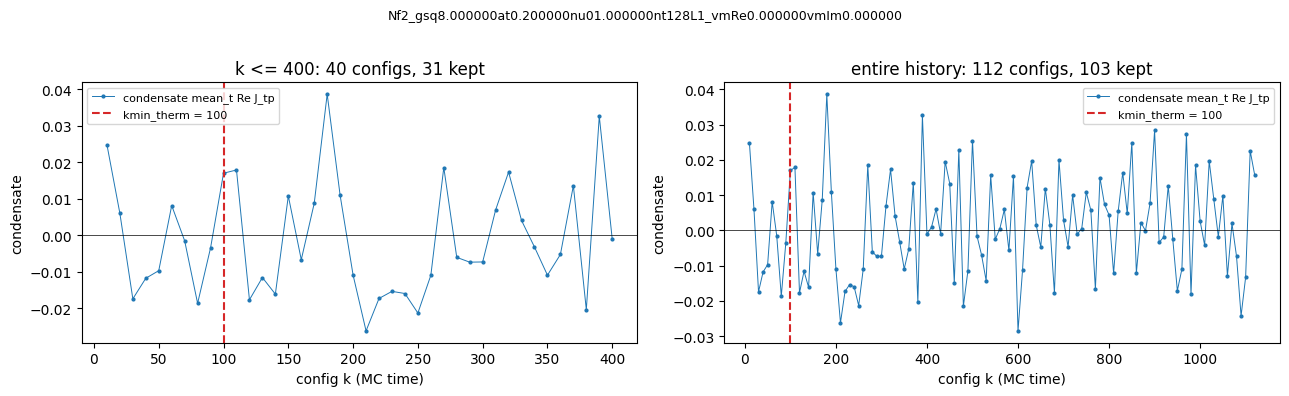

In [8]:
# ===== Block therm: disc condensate MC history + thermalization cut =====
# Per-config disc condensate = hit- and t-averaged Re J_tp(t) (the current zero-mode whose square is
# the disc DC constant).  LEFT: zoom to k<=400; RIGHT: entire history.  Pick kmin_therm in Block 0
# above the transient; the loaders then jackknife only configs with k >= kmin_therm.
ks4, c4 = load_cond_history('tp/J', kmax=400)
ka, ca  = load_cond_history('tp/J', kmax=None)
fig, ax = plt.subplots(1, 2, figsize=(13, 4))
fig.suptitle(esnid(), fontsize=9)
for a, (ks, cc, ttl) in zip(ax, [(ks4, c4, 'k <= 400'), (ka, ca, 'entire history')]):
    a.plot(ks, cc, '.-', ms=4, lw=0.7, color='C0', label='condensate mean_t Re J_tp')
    a.axhline(0.0, color='k', lw=0.5)
    a.axvline(kmin_therm, color='C3', ls='--', label='kmin_therm = %d' % kmin_therm)
    keep = ks >= kmin_therm
    a.set_xlabel('config k (MC time)'); a.set_ylabel('condensate')
    a.set_title('%s: %d configs, %d kept' % (ttl, len(ks), int(keep.sum())))
    a.legend(fontsize=8)
plt.tight_layout(rect=[0, 0, 1, 0.96])
ka_keep = ka >= kmin_therm
if ka_keep.any():
    print('entire: kept %d/%d (k>=%d)  mean=%.3e std=%.3e'
          % (int(ka_keep.sum()), len(ka), kmin_therm, ca[ka_keep].mean(), ca[ka_keep].std()))


## Block tp -- connected (vector t-folded + axial)

Temporal projection.  CFT (Eq. 4.31): the vector temporal correlator is **negative**, $\mathrm{Re}\,G_t<0$
(the dashed $-$ branch is visible).  **Vector is t-folded** ($g(\Delta t)=g(N_t-\Delta t)$, reflection-even
by cyclicity) and uses **Re only** (massless $\Rightarrow$ $\mathrm{Im}$ is pure noise, omitted; the
$\mathrm{Vmm}=\mathrm{conj}(\mathrm{Vpp})$ round-trip and $\langle\mathrm{Im}\rangle\!\approx\!0$ are printed
as checks).  **Axial $C_{A+-}$ is NOT folded** (it reflects to $C_{A-+}$, Eq. 3.57).

tp  max|Vmm-conj(Vpp)| = 0.0  ;  max|<Im Vpp>| = 6.584922099688045e-05 (massless: ~0, omitted)


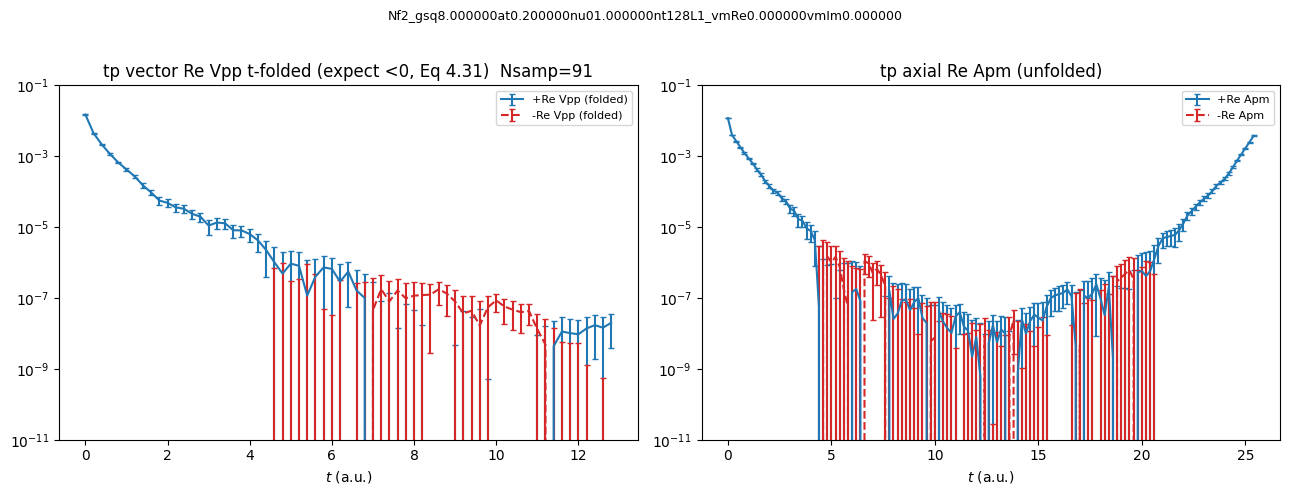

In [9]:
# ===== Block tp: VECTOR (t-folded Re; massless => Im is pure noise, OMITTED) + axial (unfolded) =====
tp_vpp = load_conn('tp/Vpp'); tp_vmm = load_conn('tp/Vmm'); tp_apm = load_conn('axial/tp/Apm')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(esnid(), fontsize=9)
nc = plot_signed_fold(ax[0], tp_vpp.real, 'Re Vpp (folded)')
ax[0].set_title('tp vector Re Vpp t-folded (expect <0, Eq 4.31)  Nsamp=%d' % nc)
# axial C_{A+-} is NOT self-reflection-even (reflects to C_{A-+}, Eq 3.57) -> NOT folded; signed Re
plot_signed(ax[1], tp_apm.real, 'Re Apm')
ax[1].set_title('tp axial Re Apm (unfolded)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
# consistency (massless): Vmm = conj(Vpp) round-trip, and Im is pure noise (omitted from the plots)
if tp_vpp.size and tp_vmm.size:
    print('tp  max|Vmm-conj(Vpp)| =', np.max(np.abs(np.mean(tp_vmm, 0) - np.conj(np.mean(tp_vpp, 0)))),
          ' ;  max|<Im Vpp>| =', np.max(np.abs(np.mean(tp_vpp.imag, 0))), '(massless: ~0, omitted)')

## Block sp -- connected (vector t-folded + axial)

Spatial projection.  CFT (Eq. 4.28): the vector spatial correlator is **positive**, $\mathrm{Re}\,G_s>0$
(the $+$ branch visible) -- opposite sign to tp, the clean control.  **Vector t-folded, Re only**
(Im omitted); axial unfolded.

sp  max|<Im Vpp>| = 5.620872716844879e-05 (massless: ~0, omitted)


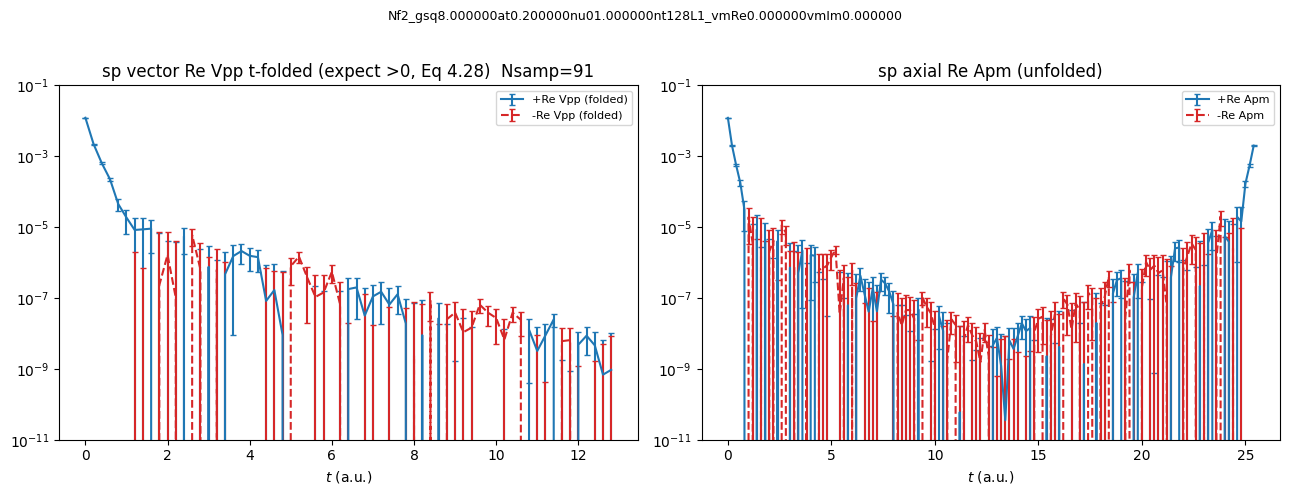

In [10]:
# ===== Block sp: VECTOR (t-folded Re; Im OMITTED) + axial (unfolded) =====
sp_vpp = load_conn('sp/Vpp'); sp_vmm = load_conn('sp/Vmm'); sp_apm = load_conn('axial/sp/Apm')
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(esnid(), fontsize=9)
nc = plot_signed_fold(ax[0], sp_vpp.real, 'Re Vpp (folded)')
ax[0].set_title('sp vector Re Vpp t-folded (expect >0, Eq 4.28)  Nsamp=%d' % nc)
plot_signed(ax[1], sp_apm.real, 'Re Apm')
ax[1].set_title('sp axial Re Apm (unfolded)')
plt.tight_layout(rect=[0, 0, 1, 0.96])
if sp_vpp.size:
    print('sp  max|<Im Vpp>| =', np.max(np.abs(np.mean(sp_vpp.imag, 0))), '(massless: ~0, omitted)')

## Block ylm -- connected towers: VECTOR (t-folded) + AXIAL (unfolded)

Spherical-harmonic tower $\ell=0,1,2$, each in its own panel.  **Top row = vector** (t-folded, Re only,
signed: $+$Re blue / $-$Re red; CFT Eqs. 4.34-4.35: $\ell=0\approx0$, $\ell=1\sim-e^{-2t}$,
$\ell=2\sim-e^{-3t}$, so the red branch is visible for $\ell\ge1$).  **Bottom row = axial $C_{A+-,\ell}$**,
**unfolded** (it reflects to $C_{A-+}$, Eq. 3.57), signed Re.  Axial ylm needs the rebuilt `jj_corr`
(key `axial/ylm/Apm/l{l}`); panels show "no data" until then.

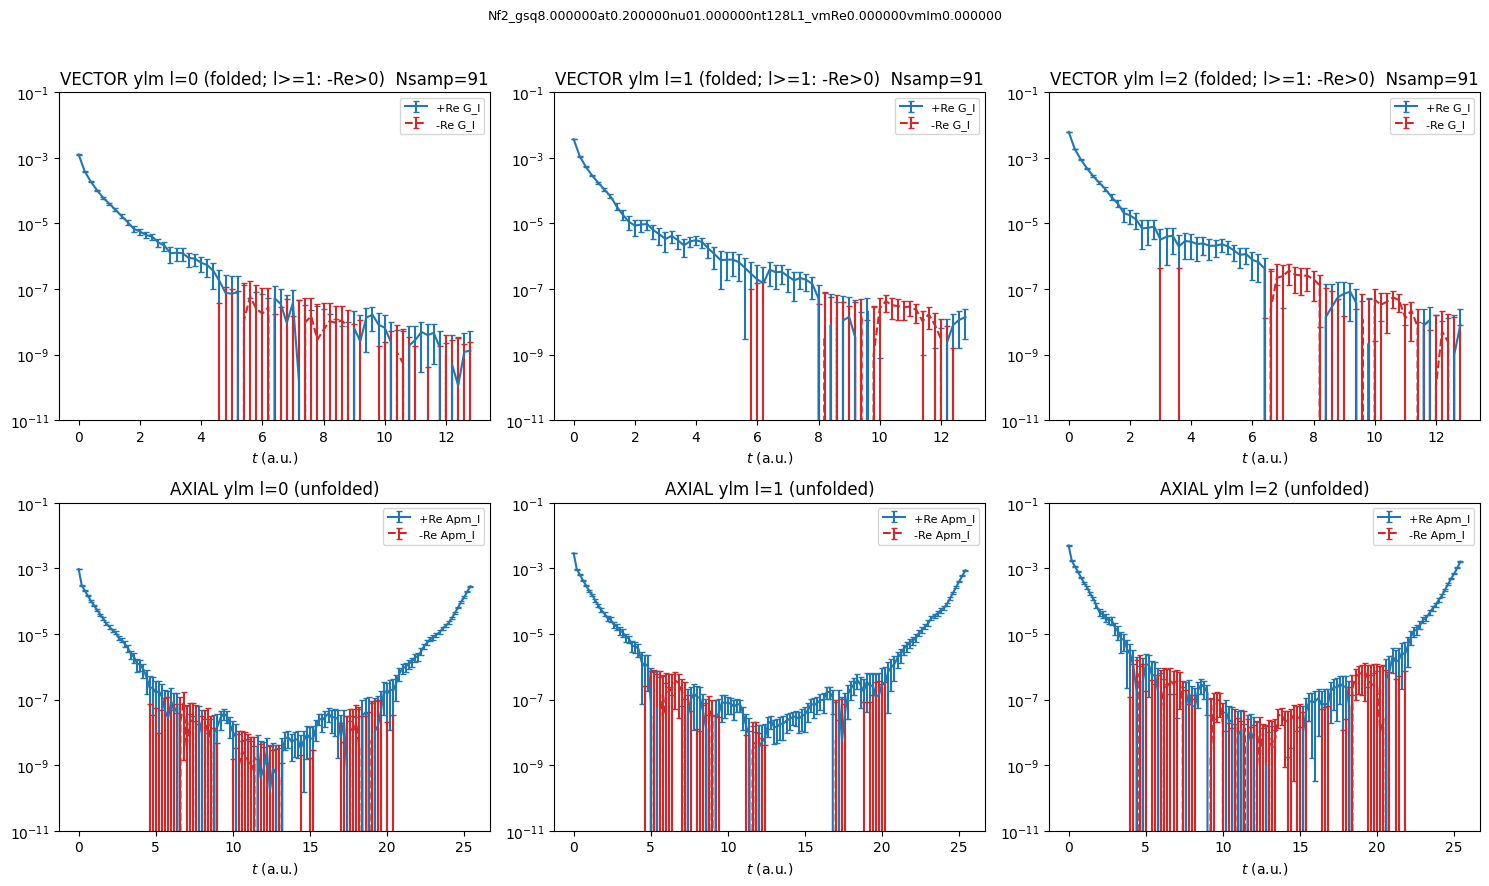

In [11]:
# ===== Block ylm: VECTOR tower (t-folded) + AXIAL tower (unfolded) -- l=0,1,2 SEPARATED =====
ylm_vpp, ylm_ls = load_ylm_conn('Vpp')
if ylm_vpp.size:
    nl = len(ylm_ls)
    fig, ax = plt.subplots(2, nl, figsize=(5*nl, 9), squeeze=False)
    fig.suptitle(esnid(), fontsize=9)
    # row 0: VECTOR, t-folded, signed (+ blue solid, - red dashed)
    for li, l in enumerate(ylm_ls):
        n = plot_signed_fold(ax[0][li], ylm_vpp[:, li, :].real, 'Re G_l')   # folds + jackknifes, n<2-safe
        ax[0][li].set_title('VECTOR ylm l=%d (folded; l>=1: -Re>0)  Nsamp=%d' % (l, n))
    # row 1: AXIAL C_{A+-} tower, UNFOLDED (reflects to C_{A-+}, Eq 3.57), signed Re
    for li, l in enumerate(ylm_ls):
        ayl = load_conn('axial/ylm/Apm/l%d' % l)     # needs the axial-ylm build of jj_corr (key axial/ylm/Apm/l{l})
        plot_signed(ax[1][li], ayl.real, 'Re Apm_l')
        ax[1][li].set_title('AXIAL ylm l=%d (unfolded)%s' % (l, '' if ayl.size else '  [no data: recompile jj_corr]'))
    plt.tight_layout(rect=[0, 0, 1, 0.96])
else:
    fig, ax = plt.subplots(1, 1, figsize=(8, 5)); ax.set_title('(no ylm data)')
    fig.suptitle(esnid(), fontsize=9)


## Block disc -- disconnected (VECTOR ONLY)

The disc two-point $C^P_\mathrm{disc}(\Delta t)=\bar J(0)\bar J(t)$ from `disc_proced.*.h5`
(produced by `jj_disc_postproc`).  Also shows the RAW single-current trace $J(t)$ from the `corr` file
(keys `h{h}/disc/...`) for inspection.  Axial has no disc.

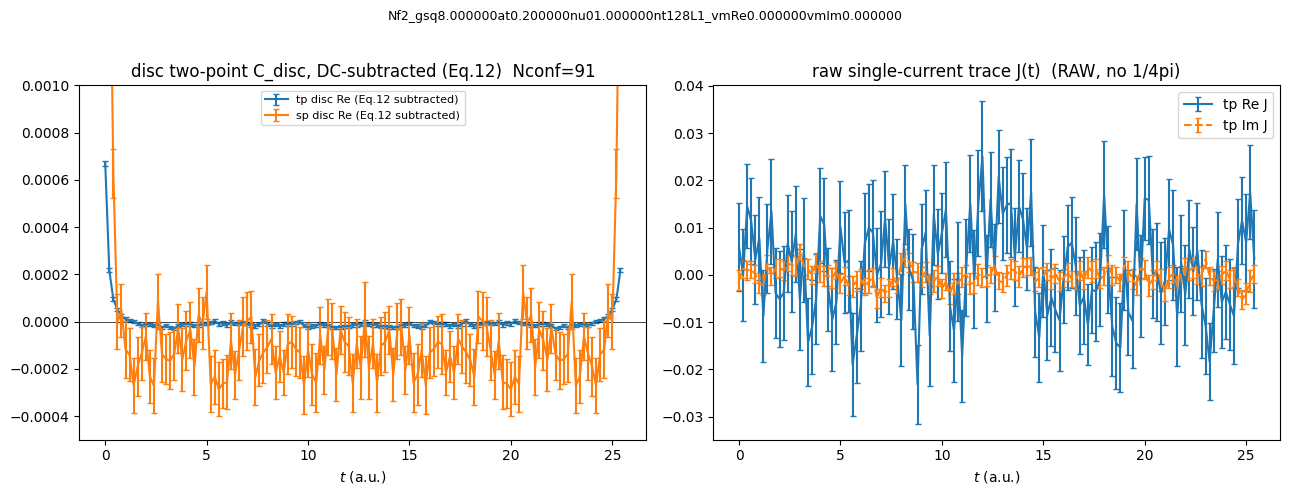

In [12]:
# ===== Block disc: disc two-point (disc_proced) + raw single-current trace J(t) =====
# Apply Eq.(12) of PhysRevD.110.054501 (DC / zero-frequency subtraction) to the disc DIAGRAM
# contribution, config by config (t = array label): Ctilde(t) = C(t) - (1/Nt) sum_t' C(t').
# This removes the unphysical t-independent vacuum constant of the p=0 disconnected correlator.
# The SUBTRACTED arrays are canonical (disc_tp/disc_sp/disc_ylm) -> the sum block uses them.
disc_tp_raw = load_dp('tp/Vpp'); disc_sp_raw = load_dp('sp/Vpp')
rawJ_tp = load_rawJ('tp/J');     rawJ_sp = load_rawJ('sp/J')
ls_for_disc = ylm_ls if ylm_ls is not None else np.array([0, 1, 2])
disc_ylm_raw = [load_dp('ylm/Vpp/l%d' % l) for l in ls_for_disc]

# Eq.(12) DC subtraction (per config, over the t-axis):
disc_tp  = vac_sub(disc_tp_raw)
disc_sp  = vac_sub(disc_sp_raw)
disc_ylm = [vac_sub(d) for d in disc_ylm_raw]

fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(esnid(), fontsize=9)
# LINEAR y axis (no log): the subtracted disc oscillates about zero.
n_tp = plot_linear(ax[0], disc_tp.real, 'tp disc Re (Eq.12 subtracted)')
jk_sp = jk_of(disc_sp.real) if disc_sp.shape[0] >= 2 else None
if jk_sp is not None:
    ax[0].errorbar(xxx, jk_sp.mean(), jk_sp.err(), capsize=2, color='C1', label='sp disc Re (Eq.12 subtracted)')
elif disc_sp.size:
    ax[0].plot(xxx, np.mean(disc_sp.real, axis=0), marker='.', color='C1', label='sp disc Re (1 sample)')
ax[0].legend(fontsize=8)
ax[0].set_title('disc two-point C_disc, DC-subtracted (Eq.12)  Nconf=%d' % (disc_tp.shape[0] if disc_tp.size else 0))

if rawJ_tp.size:
    jr = jk_of(rawJ_tp.real); ji = jk_of(rawJ_tp.imag)
    ax[1].errorbar(xxx, jr.mean(), jr.err(), capsize=2, label='tp Re J')
    ax[1].errorbar(xxx, ji.mean(), ji.err(), capsize=2, ls='--', label='tp Im J')
    ax[1].legend()
ax[1].set_xlabel('$t$ (a.u.)'); ax[1].set_title('raw single-current trace J(t)  (RAW, no 1/4pi)')


ax[0].set_ylim(-0.0005, 0.001)

plt.tight_layout(rect=[0, 0, 1, 0.96])


## Block sum -- physical correlator $-\mathrm{conn}+\mathrm{disc}$

PDF Eq. 3.39: $\frac{2}{N_f}\langle JJ\rangle = -C_\mathrm{conn}+C_\mathrm{disc}$ (bare-$C$; reweighting
$R$ multiplies later).  Vector only (axial = connected-only).  Combined per config (aligned by index).
Free massless: overlay the arXiv:2510.03085 analytical curves here (TODO).

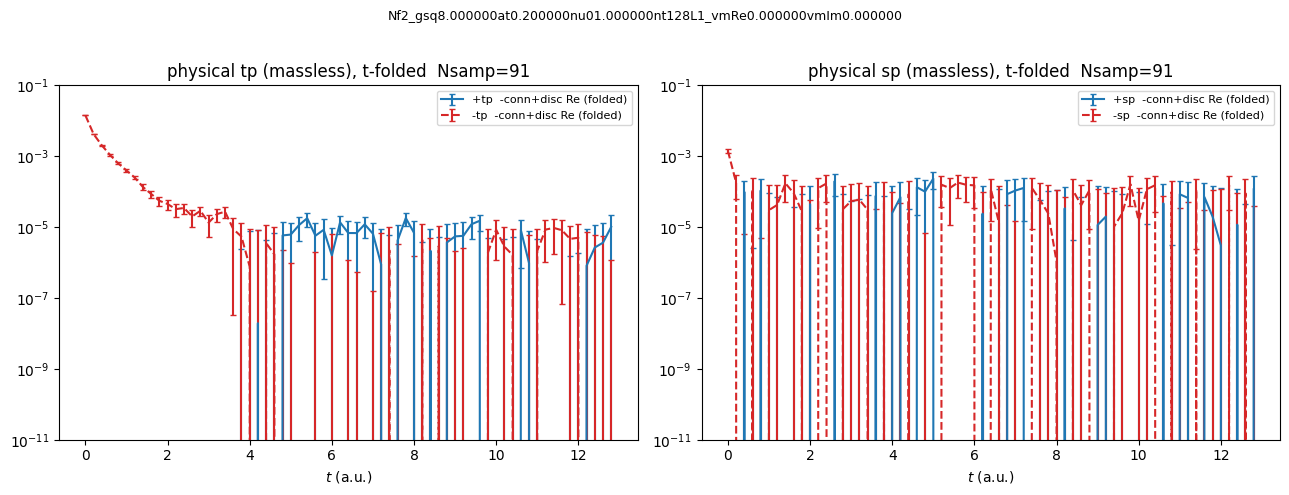

In [13]:
# ===== Block sum: physical = -conn + disc (vector), t-folded Re (Im omitted) =====
# Eq. 3.39: physical = -C_conn + C_disc (bare-C; reweighting R later).  Axial = connected-only.
# NOTE: this uses the UNSUBTRACTED (raw) disc -- literally -C_c + C_d (Block disc still PLOTS the
#       Eq.12 DC-subtracted disc; only that plot is subtracted, the physical sum is not).
# Sample-axis bookkeeping:
#   interacting (conn & disc both per-config, equal counts): combine per config -> jackknife configs.
#   free (conn = hit samples, disc_proced = 1 collapsed config): add the disc CENTRAL as a small fixed
#     correction and jackknife over the conn hit-samples.
def physical(conn, disc):
    if conn.size == 0:
        return np.array([])
    if disc.size and disc.shape[0] == conn.shape[0]:
        return -conn + disc                      # aligned per sample (interacting: per config)
    dc = np.mean(disc, axis=0) if disc.size else 0.0
    return -conn + dc                            # free: -conn(hit samples) + disc central

# def physical(conn, disc):
#     if conn.size == 0:
#         return np.array([])
#     if disc.size and disc.shape[0] == conn.shape[0]:
#         return conn + disc                      # aligned per sample (interacting: per config)
#     dc = np.mean(disc, axis=0) if disc.size else 0.0
#     return conn + dc                            # free: -conn(hit samples) + disc central

ph_tp = physical(tp_vpp, disc_tp_raw)
ph_sp = physical(sp_vpp, disc_sp_raw)
fig, ax = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle(esnid(), fontsize=9)
n_tp = plot_signed_fold(ax[0], ph_tp.real, 'tp  -conn+disc Re (folded)')
n_sp = plot_signed_fold(ax[1], ph_sp.real, 'sp  -conn+disc Re (folded)')
ax[0].set_title('physical tp (massless), t-folded  Nsamp=%d' % n_tp)
ax[1].set_title('physical sp (massless), t-folded  Nsamp=%d' % n_sp)
plt.tight_layout(rect=[0, 0, 1, 0.96])

# TODO: overlay arXiv:2510.03085 analytical massless curves (free-field validation).
if ph_tp.size == 0:
    print('NOTE: sum needs conn (corr_*.h5); disc central from disc_proced.*.h5 (run jj_disc_postproc).')